In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font family: Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family: Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding top:120px;}
div.text_cell_render ul li {font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font color="red" size="6"> 02_딥러닝입문_분류분석</font></b>
# 머신러닝/딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨인식, 문장분류, 질병진단,...
※ ML/DL의 종류
- 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
    회귀분석(타겟변수가 연속형) vs 분류분석(multi, binary)
- 비지도학습(입력변수만)
    군집화(군집분석)
- 강화학습

※ 지도학습에서의 ML, DL 프로그래밍 방식
```
1. 데이터 셋 확보(input=입력변수, target=종속변수)
    원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈련셋(학습셋), 검증셋, 시험셋(테스트셋) = 6 : 2 : 2
    학습 및 평가 가능한 포맷으로 변환(numpy, DataFrame)
3. 모델 구성
    Sequential 객체 생성뒤 필요한 층을 add()함수로 추가
4. 모델 학습과정 설정
    ※compile()함수 이용. 손실함수, optimizer, metrics(평가지표)
    ※옵티마이저 오솔길
    ※loss 손실 함수. 회귀 문제에서는 "mse" (Mean Squared Error), "mae" (Mean Absolute Error) 등
    - "mse" : 오차 제곱의 평균(이상치 영향이 확 올라감)
    - "mae" : 오차 절대값의 평균(이상치 영향이 감소)
    ※optimizer 가중치를 어떻게 업데이트할지 결정하는 알고리즘. adam, sgd, rmsprop 등이 대표적
    - "adam" 대부분의 상황에서 잘 동작함. 추천 기본값
    - "sgd" Stochastic Gradient Descent. 단순하지만 느림
    - "rmsprop" 시계열/순환 모델에 잘 작동함
    ※metrics 학습 중 모니터링할 지표 (선택 사항). 예: "mae", "mape", "accuracy" (분류 문제용) 등
5. 모델 학습시키기(ft. 학습과정 지켜보기)
    fit() 함수 이용 - 훈련셋입력=독립변수, 훈련셋타겟=종속변수, 학습횟수, 검증셋
6. 모델 평가
    시험셋(테스트셋)을 인자로 넣은 evaluate()함수 이용, 그래프
7. 모델 사용
    predict() 이용. 입력데이터는 2차원 데이터
8. 모델 저장
    save()함수이용해서 저장. 저장된 모델은 load_model()함수를 이용해서 불러올 수 있음
```

#### 분류분석  import

In [3]:
# 분류분석 import
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 1. 데이터 셋 생성
# 2. 데이터 전처리


#### 학습데이터

In [7]:
# 학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,4,6,8,10,12,14,16,18]*10)
x_train.shape, y_train.shape

((90,), (90,))

#### 검증데이터

In [8]:
# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,14,16,18])

#### 시험데이터 = 테스트셋

In [9]:
# 시험데이터 = 테스트셋
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,14,16,18])
x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((90,), (9,), (9,), (90,), (9,), (9,))

#### 인코딩 종류

In [13]:
# 인코딩 종류
data = np.array(['a','b','c','d'])
print('원 데이터 :', data)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeled_data = le.transform(data)
labeled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 : ', labeled_data)
one_hot_encoded_data = to_categorical(labeled_data)
print('원핫인코딩된 데이터 : ', one_hot_encoded_data)

원 데이터 : ['a' 'b' 'c' 'd']
라벨인코딩된 데이터 :  [0 1 2 3]
원핫인코딩된 데이터 :  [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


#### 분류 분석을 하기 위해, target변수를 원핫인코딩(라벨링 전환)

In [15]:
# 분류 분석을 하기 위해, target변수를 원핫인코딩(라벨링 전환)
data = np.array([1,2,2,4,2])
print(data)
categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩 : \n', categorical_one_hot)

import pandas as pd
get_dummies_one_hot = pd.get_dummies(data)
display('get_dummies를 이용한 원핫인코딩: ', get_dummies_one_hot)

[1 2 2 4 2]
to_categorical을 이용한 원핫인코딩 : 
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dummies를 이용한 원핫인코딩: '

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


In [18]:
# 분류 분석을 위한 target 변수 라벨링 전환(=원핫 인코딩)
Y_train = to_categorical(y_train, 19)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)
Y_test

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1.]], dtype=float32)

In [20]:
print('훈련셋 구조:', x_train.shape, Y_train.shape) # 독립변수1개, 타겟변수 19
print('검증셋 구조:', x_val.shape, Y_val.shape)
print('테스트셋 구조:', x_test.shape, Y_test.shape)

훈련셋 구조: (90,) (90, 19)
검증셋 구조: (9,) (9, 19)
테스트셋 구조: (9,) (9, 19)


# 3. 모델 구성하기

In [22]:
model = Sequential()
model.add(Input(shape=(1,))) # 입력층
model.add(Dense(units=38, activation='sigmoid')) # units출력수, 활성화함수:relu, tanh
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=19, activation='softmax'))
# softmax : 모든 출력결과의 합이 1. 분류분석 마지막 layer(출력층)에서 activation으로 사용
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 38)                76        
                                                                 
 dense_5 (Dense)             (None, 64)                2496      
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [25]:
model.compile(loss='categorical_crossentropy', # 분류분석에서의 손실함수(원핫인코딩有)
             optimizer='sgd',
             metrics=['accuracy'], # 평가지표 : accuracy
             )

# 5. 모델 학습시키기(1번만실행)
```
hist = model.fit(
    scaled_data_C, # 독립(입력)변수(훈련데이터)
    scaled_data_F, # 타겟(출력)변수(훈련데이터)
    epochs=1000,   # 학습횟수
    verbose=2, # 학습 결과 출력여부(0:학습내용출력X, 1대충 2자세히)
    #batch_size=32, # 32개씩 데이터를 잘라서 학습 -> 한번에 32개만 처리
    #validation_data=() # 학습 중간에 성능 평가할 검증 데이터
    )
```

In [26]:
hist = model.fit(x_train, Y_train,
                epochs=300,
                batch_size=10,
                verbose=2, # 학습 결과 출력 옵션(0:출력없음, 1:기본값, 2:에포크별로그 상세출력)
                validation_data=(x_val, Y_val),
                )

Epoch 1/300
9/9 - 1s - loss: 2.7805 - accuracy: 0.0667 - val_loss: 2.6642 - val_accuracy: 0.1111 - 587ms/epoch - 65ms/step
Epoch 2/300
9/9 - 0s - loss: 2.6258 - accuracy: 0.1111 - val_loss: 2.5499 - val_accuracy: 0.1111 - 46ms/epoch - 5ms/step
Epoch 3/300
9/9 - 0s - loss: 2.5303 - accuracy: 0.1111 - val_loss: 2.4732 - val_accuracy: 0.1111 - 45ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.4652 - accuracy: 0.1444 - val_loss: 2.4172 - val_accuracy: 0.1111 - 44ms/epoch - 5ms/step
Epoch 5/300
9/9 - 0s - loss: 2.4202 - accuracy: 0.1667 - val_loss: 2.3729 - val_accuracy: 0.1111 - 48ms/epoch - 5ms/step
Epoch 6/300
9/9 - 0s - loss: 2.3739 - accuracy: 0.1222 - val_loss: 2.3346 - val_accuracy: 0.2222 - 45ms/epoch - 5ms/step
Epoch 7/300
9/9 - 0s - loss: 2.3369 - accuracy: 0.2111 - val_loss: 2.3028 - val_accuracy: 0.1111 - 44ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.3068 - accuracy: 0.1889 - val_loss: 2.2756 - val_accuracy: 0.1111 - 42ms/epoch - 5ms/step
Epoch 9/300
9/9 - 0s - loss: 2

Epoch 69/300
9/9 - 0s - loss: 1.5876 - accuracy: 0.4111 - val_loss: 1.5477 - val_accuracy: 0.6667 - 62ms/epoch - 7ms/step
Epoch 70/300
9/9 - 0s - loss: 1.5705 - accuracy: 0.4667 - val_loss: 1.5414 - val_accuracy: 0.5556 - 45ms/epoch - 5ms/step
Epoch 71/300
9/9 - 0s - loss: 1.5656 - accuracy: 0.5111 - val_loss: 1.5285 - val_accuracy: 0.5556 - 43ms/epoch - 5ms/step
Epoch 72/300
9/9 - 0s - loss: 1.5518 - accuracy: 0.4111 - val_loss: 1.5192 - val_accuracy: 0.4444 - 43ms/epoch - 5ms/step
Epoch 73/300
9/9 - 0s - loss: 1.5420 - accuracy: 0.4000 - val_loss: 1.5070 - val_accuracy: 0.4444 - 43ms/epoch - 5ms/step
Epoch 74/300
9/9 - 0s - loss: 1.5352 - accuracy: 0.4222 - val_loss: 1.4975 - val_accuracy: 0.6667 - 42ms/epoch - 5ms/step
Epoch 75/300
9/9 - 0s - loss: 1.5233 - accuracy: 0.4556 - val_loss: 1.4887 - val_accuracy: 0.5556 - 42ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - loss: 1.5090 - accuracy: 0.5778 - val_loss: 1.4795 - val_accuracy: 0.4444 - 42ms/epoch - 5ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 1.0679 - accuracy: 0.7667 - val_loss: 1.0381 - val_accuracy: 0.8889 - 60ms/epoch - 7ms/step
Epoch 137/300
9/9 - 0s - loss: 1.0626 - accuracy: 0.7778 - val_loss: 1.0357 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 138/300
9/9 - 0s - loss: 1.0650 - accuracy: 0.7333 - val_loss: 1.0299 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 139/300
9/9 - 0s - loss: 1.0609 - accuracy: 0.8222 - val_loss: 1.0304 - val_accuracy: 0.7778 - 42ms/epoch - 5ms/step
Epoch 140/300
9/9 - 0s - loss: 1.0591 - accuracy: 0.6556 - val_loss: 1.0207 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 141/300
9/9 - 0s - loss: 1.0425 - accuracy: 0.7667 - val_loss: 1.0101 - val_accuracy: 0.7778 - 42ms/epoch - 5ms/step
Epoch 142/300
9/9 - 0s - loss: 1.0272 - accuracy: 0.8556 - val_loss: 1.0063 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 143/300
9/9 - 0s - loss: 1.0380 - accuracy: 0.8111 - val_loss: 0.9998 - val_accuracy: 0.7778 - 43ms/epoch - 5ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.7913 - accuracy: 0.8000 - val_loss: 0.7340 - val_accuracy: 1.0000 - 53ms/epoch - 6ms/step
Epoch 204/300
9/9 - 0s - loss: 0.7414 - accuracy: 0.9444 - val_loss: 0.7417 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7596 - accuracy: 0.8889 - val_loss: 0.7241 - val_accuracy: 1.0000 - 40ms/epoch - 4ms/step
Epoch 206/300
9/9 - 0s - loss: 0.7560 - accuracy: 0.8667 - val_loss: 0.7356 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 207/300
9/9 - 0s - loss: 0.7514 - accuracy: 0.8222 - val_loss: 0.7398 - val_accuracy: 0.8889 - 48ms/epoch - 5ms/step
Epoch 208/300
9/9 - 0s - loss: 0.7765 - accuracy: 0.8667 - val_loss: 0.7142 - val_accuracy: 0.8889 - 46ms/epoch - 5ms/step
Epoch 209/300
9/9 - 0s - loss: 0.7382 - accuracy: 0.8778 - val_loss: 0.7204 - val_accuracy: 0.7778 - 45ms/epoch - 5ms/step
Epoch 210/300
9/9 - 0s - loss: 0.7472 - accuracy: 0.8556 - val_loss: 0.7102 - val_accuracy: 0.8889 - 45ms/epoch - 5ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.5347 - accuracy: 0.9111 - val_loss: 0.5370 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5718 - accuracy: 0.8889 - val_loss: 0.5176 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 272/300
9/9 - 0s - loss: 0.5626 - accuracy: 0.9111 - val_loss: 0.5246 - val_accuracy: 1.0000 - 44ms/epoch - 5ms/step
Epoch 273/300
9/9 - 0s - loss: 0.5566 - accuracy: 0.9333 - val_loss: 0.5154 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 274/300
9/9 - 0s - loss: 0.5272 - accuracy: 0.9667 - val_loss: 0.5111 - val_accuracy: 1.0000 - 40ms/epoch - 4ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5439 - accuracy: 0.9222 - val_loss: 0.5195 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 276/300
9/9 - 0s - loss: 0.5291 - accuracy: 0.9556 - val_loss: 0.5062 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 277/300
9/9 - 0s - loss: 0.5261 - accuracy: 0.9556 - val_loss: 0.5297 - val_accuracy: 0.7778 - 42ms/epoch - 5ms/step
Epoch 278/300
9/

# 6. 모델 평가하기(모델학습과정 살펴보고, evaluate)

In [28]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

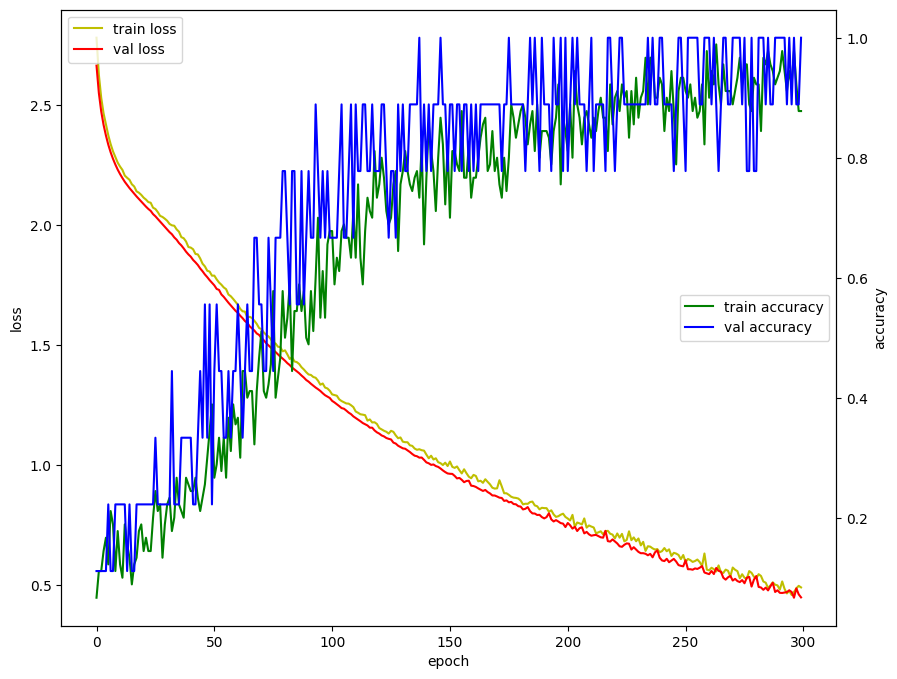

In [34]:
# 모델 학습과정 시각화
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,8))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax생성
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc='center right')

plt.show()

#### 모델 평가하기

In [35]:
# 모델 평가하기
score = model.evaluate(x_test, Y_test, batch_size=1)

9/9 [==============================] - 0s 2ms/step - loss: 0.4473 - accuracy: 1.0000


In [36]:
score # loss, accuracy

[0.44734227657318115, 1.0]

In [42]:
print('평가된 loss :', score[0])
print('평가된 accuracy :', score[1]*100,'%')

평가된 loss : 0.44734227657318115


AttributeError: 'tuple' object has no attribute 'strip'

# 7. 모델 사용하기

In [41]:
H = model.predict(np.array([[2]]))
H

1/1 [==============================] - 0s 127ms/step


array([[7.4165521e-11, 1.5523174e-12, 9.4784707e-02, 1.9713862e-10,
        7.9548973e-01, 2.7418744e-13, 1.0835743e-01, 1.7970930e-12,
        1.3658594e-03, 2.2620922e-12, 2.2822555e-06, 5.3548828e-09,
        4.6432098e-09, 4.9928706e-09, 5.8725458e-13, 2.1811965e-11,
        4.0783950e-18, 2.2940515e-14, 1.7235715e-25]], dtype=float32)

#### 분류분석의 예측은 predict의 결과를 argmax()하면 됨(예측값) 

In [43]:
# 분류분석의 예측은 predict의 결과를 argmax()하면 됨(예측값)
model.predict(np.array([[2]])).argmax()

1/1 [==============================] - 0s 34ms/step


4

In [47]:
# 4를 몇%확률로 예측했는지
H[0, H.argmax()]*100

79.54897284507751

# 7. 모델 저장하기

In [49]:
model.save('model/02_deep.h5')

# 텐서플로우 최신버전은 save가 안되서 아래 방법 사용
# from tensorflow.keras.models import save_model
# save_model(model, 'model/02_deep.h5')

## 저장된 모델 사용하기

In [50]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')